# `mosaic(aoi=...)` - Sentinel-2 mosaics for polygon AOIs

Polygon AOIs are useful for long, narrow, or irregular areas where a rectangular bounds mosaic would read many pixels outside the area of interest. They are usually cheaper than rectangular bounds for corridor-style targets.

In [ ]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
from shapely.geometry import Polygon

from s2mosaic import mosaic


def plot_rgb(array, title=None, figsize=(8, 6), background=(0.85, 0.85, 0.85)):
    """Display B04/B03/B02-style arrays with a robust percentile stretch.

    Nodata / zero pixels are filled with `background` so dark water is easy to
    distinguish from the area outside the AOI.
    """
    rgb = np.moveaxis(array[:3], 0, -1).astype(float)
    valid_mask = np.all(np.isfinite(rgb) & (rgb > 0), axis=-1)
    valid = rgb[valid_mask]
    if valid.size == 0:
        raise ValueError("No positive finite pixels to display")
    lo, hi = np.nanpercentile(valid, [2, 98])
    if not np.isfinite(hi - lo) or hi <= lo:
        hi = np.nanmax(valid)
        lo = np.nanmin(valid)
    rgb_disp = np.clip((rgb - lo) / max(hi - lo, 1), 0, 1)
    rgb_disp[~valid_mask] = background

    plt.figure(figsize=figsize)
    plt.imshow(rgb_disp)
    if title:
        plt.title(title)
    plt.axis("off")
    plt.show()

## 1. Define a polygon

Define a single valid shapely `Polygon`. The default `input_crs` is EPSG:4326, so these coordinates are lon/lat.

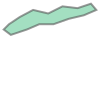

In [2]:
# Winding corridor-style AOI near Perth, WA: non-convex and irregular.
aoi = Polygon(
    [
        (115.920, -31.945),
        (115.905, -31.950),
        (115.888, -31.948),
        (115.872, -31.956),
        (115.855, -31.952),
        (115.840, -31.960),
        (115.828, -31.968),
        (115.822, -31.974),
        (115.830, -31.980),
        (115.848, -31.974),
        (115.862, -31.968),
        (115.878, -31.968),
        (115.895, -31.962),
        (115.912, -31.958),
        (115.926, -31.952),
    ]
)

assert aoi.is_valid
aoi

## 2. Build a polygon mosaic

The output raster is still rectangular, using the polygon bounds, but pixels outside the polygon are skipped during aggregation and written as nodata.

In [3]:
array, profile = mosaic(
    aoi=aoi,
    input_crs=4326,
    start_year=2023,
    start_month=6,
    start_day=1,
    duration_months=2,
    bands=["B04", "B03", "B02"],
    mosaic_method="percentile",
    percentile=50,
    # Use cloud_mask="SCL" on CPU-only machines for a cheaper mask.
    resolution=10,
    min_observations=3,
    show_progress=True,
    source="AWS",
)

print(f"Shape: {array.shape}")
print(f"CRS:   {profile['crs']}")
print(f"Pixel: {profile['transform'].a}m")

Phase 1: streaming cloud masks (OCM):   0%|          | 0/11 [00:00<?, ?scene/s]

Phase 2: aggregating tiles (percentile):   0%|          | 0/24 [00:00<?, ?read/s]

Shape: (3, 397, 980)
CRS:   EPSG:32750
Pixel: 10.0m


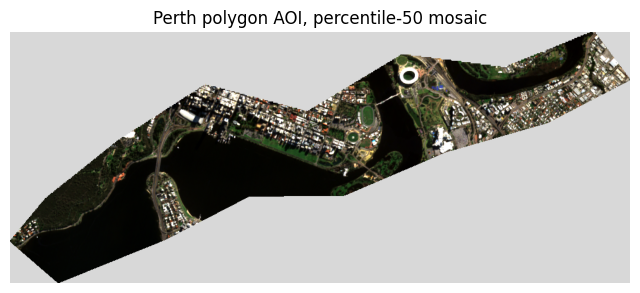

In [4]:
plot_rgb(array, "Perth polygon AOI, percentile-50 mosaic")

## 3. Export directly

Pass an `output_path` or `output_dir` to write a GeoTIFF. The returned value is the written path; a matching `.json` sidecar contains the request metadata.

In [5]:
out_path = mosaic(
    aoi=aoi,
    input_crs=4326,
    start_year=2023,
    start_month=6,
    start_day=1,
    duration_months=2,
    bands=["B04", "B03", "B02"],
    mosaic_method="first",
    cloud_mask="SCL",
    resolution=10,
    output_path=Path("output/perth_aoi_first.tif"),
)

metadata_path = out_path.with_suffix(".json")
metadata = json.loads(metadata_path.read_text())
print(f"Saved to: {out_path}")
summary = {
    "mode": metadata["mode"],
    "start_date": metadata["start_date"],
    "end_date": metadata["end_date"],
}
summary.update(
    {
        key: metadata["request"][key]
        for key in ["bands", "mosaic_method", "cloud_mask", "resolution"]
    }
)
print(summary)

Saved to: output/perth_aoi_first.tif
{'mode': 'aoi', 'start_date': '2023-06-01', 'end_date': '2023-08-01', 'bands': ['B04', 'B03', 'B02'], 'mosaic_method': 'first', 'cloud_mask': 'SCL', 'resolution': 10}
